In [49]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df=pd.read_csv("Banking.csv")

In [4]:
df.head()

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Client ID                 3000 non-null   object 
 1   Name                      3000 non-null   object 
 2   Age                       3000 non-null   int64  
 3   Location ID               3000 non-null   int64  
 4   Joined Bank               3000 non-null   object 
 5   Banking Contact           3000 non-null   object 
 6   Nationality               3000 non-null   object 
 7   Occupation                3000 non-null   object 
 8   Fee Structure             3000 non-null   object 
 9   Loyalty Classification    3000 non-null   object 
 10  Estimated Income          3000 non-null   float64
 11  Superannuation Savings    3000 non-null   float64
 12  Amount of Credit Cards    3000 non-null   int64  
 13  Credit Card Balance       3000 non-null   float64
 14  Bank Loa

In [6]:
df.describe()

,Age,Location ID,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


In [10]:
df.isnull().sum()

Client_ID                   0
Name                        0
Age                         0
Location_ID                 0
Joined_Bank                 0
Banking_Contact             0
Nationality                 0
Occupation                  0
Fee_Structure               0
Loyalty_Classification      0
Estimated_Income            0
Superannuation_Savings      0
Amount_of_Credit_Cards      0
Credit_Card_Balance         0
Bank_Loans                  0
Bank_Deposits               0
Checking_Accounts           0
Saving_Accounts             0
Foreign_Currency_Account    0
Business_Lending            0
Properties_Owned            0
Risk_Weighting              0
BRId                        0
GenderId                    0
IAId                        0
dtype: int64

First Lets Start With Data Cleaning 

1.Cleaning Column Names 

In [9]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

2.Droping Unnecessary Columns 

In [13]:
df.drop([
    'Client_ID',
    'Name',
    'Banking_Contact',
    'BRId',
    'IAId'
],axis=1,inplace=True)
    

3.Converting Date Properly

In [14]:
df['Joined_Bank']=pd.to_datetime(df['Joined_Bank'],dayfirst=True)

Creating Income Band 

In [15]:
df['Income_Band']=pd.cut(
    df['Estimated_Income'],
    bins=[0,50000,150000,1000000],
    labels=['Low','Medium','High']
)

Creating Age Group Band

In [17]:
df['Age_Group']=pd.cut(
    df['Age'],
    bins=[0,30,60,100],
    labels=['Yong','Middle','Senior']
)


Gender Mapping

In [20]:
df['Gender']=df['GenderId'].map({1:'Male',2:'Female'})

Total Balance

In [21]:
df['Total_Balance']=(df['Bank_Deposits'] +
    df['Checking_Accounts'] +
    df['Saving_Accounts']
)

Handling Outliers 

In [24]:
for col in ['Estimated_Income','Bank_Loans','Bank_Deposits']:
    df[col] = df[col].clip(
        lower=df[col].quantile(0.01),
        upper=df[col].quantile(0.99)
    )

Re Checking 

In [26]:
df.head()

,Age,Location_ID,Joined_Bank,Nationality,Occupation,Fee_Structure,Loyalty_Classification,Estimated_Income,Superannuation_Savings,Amount_of_Credit_Cards,...,Saving_Accounts,Foreign_Currency_Account,Business_Lending,Properties_Owned,Risk_Weighting,GenderId,Income_Band,Age_Group,Gender,Total_Balance
0,24,34324,2019-05-06,American,Safety Technician IV,High,Jade,75384.77,17677.95,1,...,607332.46,12249.96,1134475.30,1,2,1,Medium,Yong,Male,2696778.98
1,23,42205,2001-12-10,African,Software Consultant,High,Jade,289834.31,17398.92,1,...,344635.16,61162.31,2000526.10,1,3,1,High,Yong,Male,1215639.32
2,27,7314,2010-01-25,European,Help Desk Operator,High,Gold,169935.23,42825.90,2,...,203054.35,79071.78,548137.58,1,3,2,High,Yong,Female,1889130.63
3,40,34594,2019-03-28,American,Geologist II,Mid,Silver,356808.11,5473.15,2,...,234685.02,57513.65,1148402.29,0,4,1,High,Middle,Male,2331000.00
4,46,41269,2012-07-20,American,Assistant Professor,Mid,Platinum,130711.68,48077.60,1,...,128351.45,30012.14,1674412.12,0,3,2,Medium,Middle,Female,1062778.23


In [28]:
df.describe()

,Age,Location_ID,Joined_Bank,Estimated_Income,Superannuation_Savings,Amount_of_Credit_Cards,Credit_Card_Balance,Bank_Loans,Bank_Deposits,Checking_Accounts,Saving_Accounts,Foreign_Currency_Account,Business_Lending,Properties_Owned,Risk_Weighting,GenderId,Total_Balance
count,3000.000000,3000.000000,3000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3.000000e+03
mean,51.039667,21563.323000,2010-08-15 00:03:21.600000,171110.664756,25531.599673,1.463667,3176.206943,5.891807e+05,6.681265e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,1.504000,1.225561e+06
min,17.000000,12.000000,1995-01-03 00:00:00,23362.660500,1482.030000,1.000000,1.170000,2.288188e+04,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,0.000000e+00
25%,34.000000,10803.500000,2004-04-01 18:00:00,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,1.000000,4.387307e+05
50%,51.000000,21129.500000,2011-02-18 00:00:00,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,2.000000,9.117469e+05
75%,69.000000,32054.500000,2017-12-24 06:00:00,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,2.000000,1.696923e+06
max,85.000000,43369.000000,2021-12-31 00:00:00,475538.921100,75963.900000,3.000000,13991.990000,1.996291e+06,2.999042e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,2.000000,6.422951e+06
std,19.854760,12462.273017,NaN,111239.929503,16259.950770,0.676387,2497.094709,4.487966e+05,6.317100e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,0.500067,1.068081e+06


In [30]:
df['Age_Group'] = df['Age_Group'].replace('Yong', 'Young')

In [31]:
df.head()

,Age,Location_ID,Joined_Bank,Nationality,Occupation,Fee_Structure,Loyalty_Classification,Estimated_Income,Superannuation_Savings,Amount_of_Credit_Cards,...,Saving_Accounts,Foreign_Currency_Account,Business_Lending,Properties_Owned,Risk_Weighting,GenderId,Income_Band,Age_Group,Gender,Total_Balance
0,24,34324,2019-05-06,American,Safety Technician IV,High,Jade,75384.77,17677.95,1,...,607332.46,12249.96,1134475.30,1,2,1,Medium,Young,Male,2696778.98
1,23,42205,2001-12-10,African,Software Consultant,High,Jade,289834.31,17398.92,1,...,344635.16,61162.31,2000526.10,1,3,1,High,Young,Male,1215639.32
2,27,7314,2010-01-25,European,Help Desk Operator,High,Gold,169935.23,42825.90,2,...,203054.35,79071.78,548137.58,1,3,2,High,Young,Female,1889130.63
3,40,34594,2019-03-28,American,Geologist II,Mid,Silver,356808.11,5473.15,2,...,234685.02,57513.65,1148402.29,0,4,1,High,Middle,Male,2331000.00
4,46,41269,2012-07-20,American,Assistant Professor,Mid,Platinum,130711.68,48077.60,1,...,128351.45,30012.14,1674412.12,0,3,2,Medium,Middle,Female,1062778.23


In [33]:
df.to_csv("clean_banking_data.csv", index=False)

Lets Start With EDA 

1.Customer Distribution Segmentation

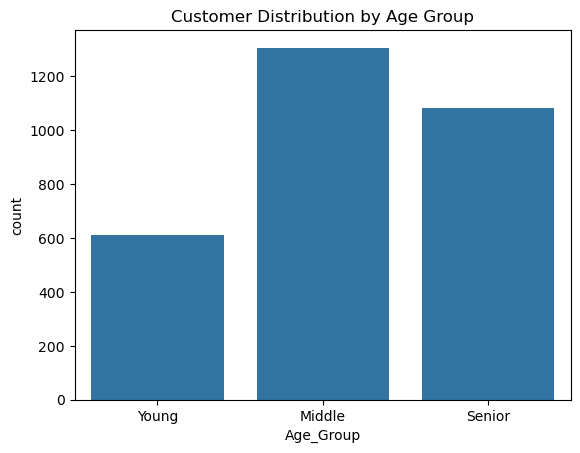

In [34]:
sns.countplot(x='Age_Group',data=df)
plt.title("Customer Distribution by Age Group")
plt.show()

2.Income VS Loan

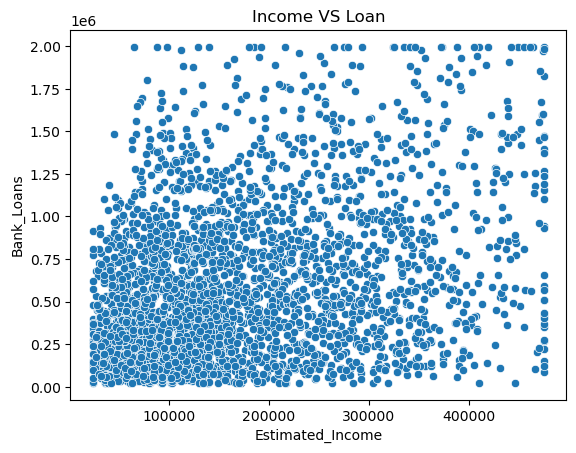

In [38]:
sns.scatterplot(x='Estimated_Income',y='Bank_Loans',data=df)
plt.title("Income VS Loan")
plt.show()


3.Loan by Income Band 

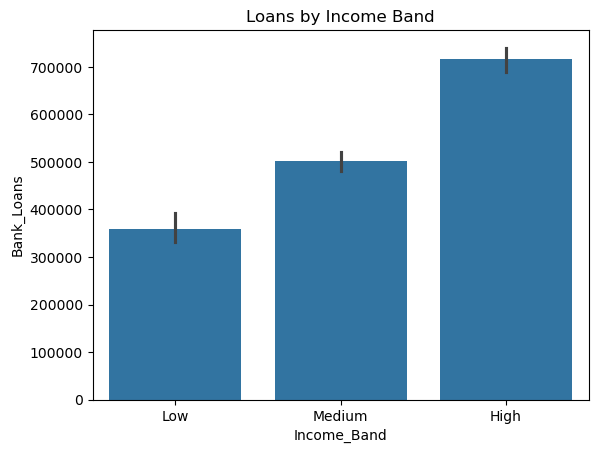

In [39]:
sns.barplot(x='Income_Band',y='Bank_Loans',data=df)
plt.title("Loans by Income Band")
plt.show()

4.Correlation Heatmap(Relationship Beatween income, loans, deposits)

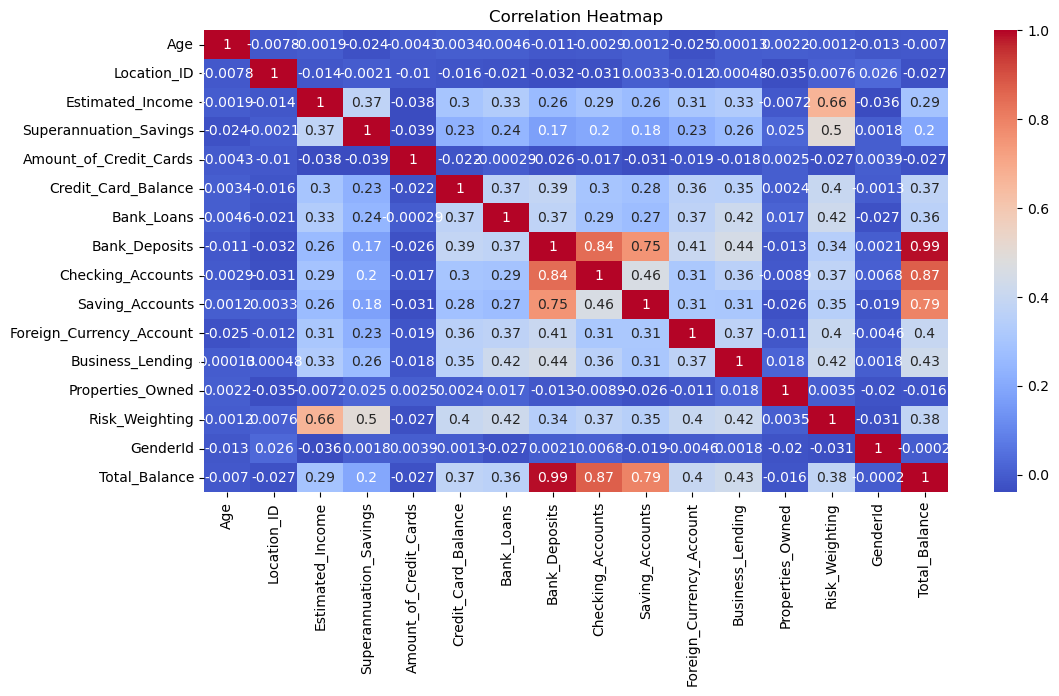

In [41]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Lets see top 10 High Value Customers:
Customers with high deposits = high-value customers

In [42]:
df.sort_values(by='Total_Balance', ascending=False).head(10)

,Age,Location_ID,Joined_Bank,Nationality,Occupation,Fee_Structure,Loyalty_Classification,Estimated_Income,Superannuation_Savings,Amount_of_Credit_Cards,...,Saving_Accounts,Foreign_Currency_Account,Business_Lending,Properties_Owned,Risk_Weighting,GenderId,Income_Band,Age_Group,Gender,Total_Balance
2307,58,38258,2020-03-23,European,VP Quality Control,High,Jade,296377.2000,34470.90,1,...,1385917.65,62491.21,3307776.77,1,4,2,High,Middle,Female,6422950.77
1132,42,29749,2014-09-27,European,Research Assistant II,Mid,Gold,215591.4600,68085.14,3,...,1724118.36,50691.15,3266701.76,1,5,2,High,Middle,Female,6381811.25
640,34,11154,2021-12-04,Asian,Safety Technician II,High,Jade,446770.8100,20431.73,2,...,482631.15,49155.13,1156672.62,2,4,1,High,Middle,Male,6343152.31
1819,49,12021,2002-08-02,European,Software Engineer IV,High,Gold,475538.9211,71291.72,2,...,848030.45,73386.45,1001806.58,0,5,2,High,Middle,Female,6309921.46
1643,76,624,2018-05-09,American,Human Resources Assistant II,Low,Silver,94314.4800,15868.80,1,...,471906.57,77808.76,951559.94,3,5,2,Medium,Senior,Female,6100375.51
2594,35,20345,2011-08-16,American,Software Engineer I,High,Jade,229131.6900,17152.18,1,...,1566778.15,119004.85,284163.08,0,5,1,High,Middle,Male,5882909.80
2363,56,10656,2014-06-29,Australian,Automation Specialist IV,Mid,Gold,168060.9400,18416.95,1,...,1574475.78,56295.08,3269918.55,1,4,2,High,Middle,Female,5857695.77
2109,31,20665,2010-02-14,European,Systems Administrator II,High,Gold,289369.8800,7043.52,1,...,1507703.66,116058.03,1032660.40,2,4,1,High,Middle,Male,5798307.08
975,34,9776,1999-05-25,Asian,Software Engineer III,High,Jade,475538.9211,48809.20,1,...,1241535.07,121035.00,1301616.99,1,4,1,High,Middle,Male,5605641.55
1921,74,2202,2004-07-05,Asian,Cost Accountant,Low,Jade,190245.7700,38707.30,1,...,1277139.63,30685.30,310266.10,2,4,2,High,Senior,Female,5565056.80


Lets jump into ML now 


Step 1: Selecting Features 

In [45]:
features=df[[
    'Estimated_Income',
    'Bank_Loans',
    'Bank_Deposits',
    'Total_Balance'
]] 

Step 2: Scalig The Data 

In [48]:
scaler=StandardScaler()
scaled_data=scaler.fit_transform(features)

Step 3:Finding Optimal Clusters(Elbow Method)

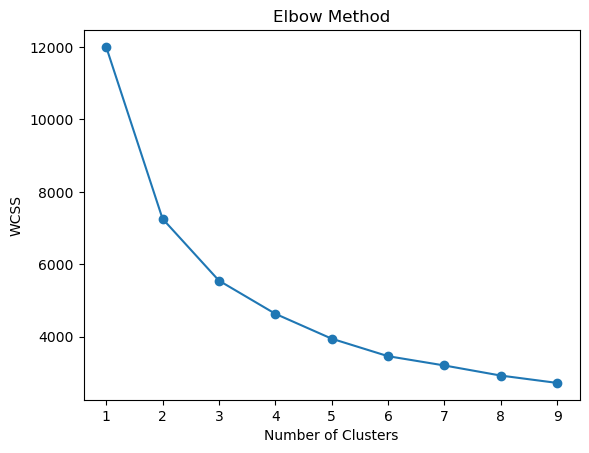

In [50]:
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

Step 4:Applying K-Means by Assumeing k=4

In [51]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

Step 5: Visualizing Cluster 

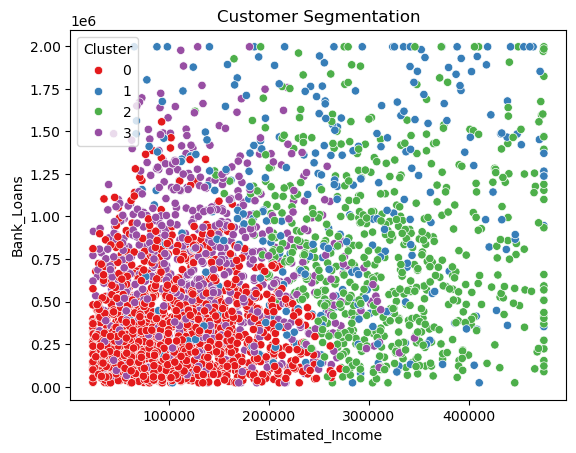

In [52]:
sns.scatterplot(
    x='Estimated_Income',
    y='Bank_Loans',
    hue='Cluster',
    data=df,
    palette='Set1'
)
plt.title("Customer Segmentation")
plt.show()

Step 6: Understanding Each Cluster

In [53]:
df.groupby('Cluster')[[
    'Estimated_Income',
    'Bank_Loans',
    'Bank_Deposits',
    'Total_Balance'
]].mean()

,Estimated_Income,Bank_Loans,Bank_Deposits,Total_Balance
Cluster,,,,
0,103816.561137,3.450670e+05,2.722025e+05,5.510529e+05
1,262156.672816,1.062330e+06,2.091485e+06,3.586497e+06
2,317790.396403,7.688092e+05,4.837662e+05,9.676834e+05
3,135566.844331,7.132164e+05,1.004808e+06,1.777104e+06


In [54]:
df['Segment'] = df['Cluster'].map({
    0: 'Low Value',
    1: 'VIP',
    2: 'Conservative',
    3: 'High Risk'
})

In [56]:
df.to_csv("final_banking_data.csv", index=False)